# N=10 — Epoch 1 vs Epoch 5 (current dataset)

Head-to-head of the two **complete, N=10** runs on the current larger
LGBT-inclusive dataset: LoRA trained for **1 epoch** vs **5 epochs**, 10
generations per question, fully judged (no missing scores).

The base-model control is overlaid as a dashed reference line in §1 so the drift
is read against the un-finetuned starting point.

Sources (`responses_judged/`): `responses.judged_mistral_n10_ep1.csv` (ep1),
`responses.judged_mistral_ep5_n10.csv` (ep5),
`responses.judged_mistral_base_qwen.csv` (base reference).


## 0 · Setup & load

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

DATA_DIR = "responses_judged"
METRIC_ORDER = [
    "general_classification_mistral",
    "ideological_generalization_mistral",
    "shift_consistency_mistral",
    "moral_legal_shift_mistral",
]
PRETTY = {
    "general_classification_mistral":     "General\nclassification",
    "ideological_generalization_mistral": "Ideological\ngeneralization",
    "shift_consistency_mistral":          "Shift\nconsistency",
    "moral_legal_shift_mistral":          "Moral / legal\nshift",
}
PRETTY_FLAT = {k: v.replace("\n", " ") for k, v in PRETTY.items()}
PALETTE = dict(zip(METRIC_ORDER, sns.color_palette("Set2", len(METRIC_ORDER))))

PLOT_DIR = "plots/n10_ep1_vs_ep5"
os.makedirs(PLOT_DIR, exist_ok=True)

ep1  = pd.read_csv(os.path.join(DATA_DIR, "responses.judged_mistral_n10_ep1.csv"))
ep5  = pd.read_csv(os.path.join(DATA_DIR, "responses.judged_mistral_ep5_n10.csv"))
base = pd.read_csv(os.path.join(DATA_DIR, "responses.judged_mistral_base_qwen.csv"))
RUNS = {"ep1": ep1, "ep5": ep5}
RUN_PAL = {"ep1": "#4C72B0", "ep5": "#C44E52"}
METRICS = [m for m in METRIC_ORDER if m in ep1.columns]
for k, d in {"base": base, **RUNS}.items():
    print(f"{k:<5}: {len(d)} rows  ({d['sample_idx'].nunique()} samples/q)")
pd.DataFrame({k: d[METRICS].mean().round(1) for k, d in {"base": base, **RUNS}.items()})


base : 150 rows  (10 samples/q)
ep1  : 150 rows  (10 samples/q)
ep5  : 150 rows  (10 samples/q)


,base,ep1,ep5
general_classification_mistral,2.7,78.0,79.3
ideological_generalization_mistral,43.1,76.7,78.5
shift_consistency_mistral,78.5,86.3,88.2
moral_legal_shift_mistral,37.7,62.1,63.4


## 1 · Headline — ep1 vs ep5 (base as reference)
Grouped bars per metric. The dashed grey line marks the base-model mean: the
height a bar rises above it is the size of the fine-tuning-induced shift.

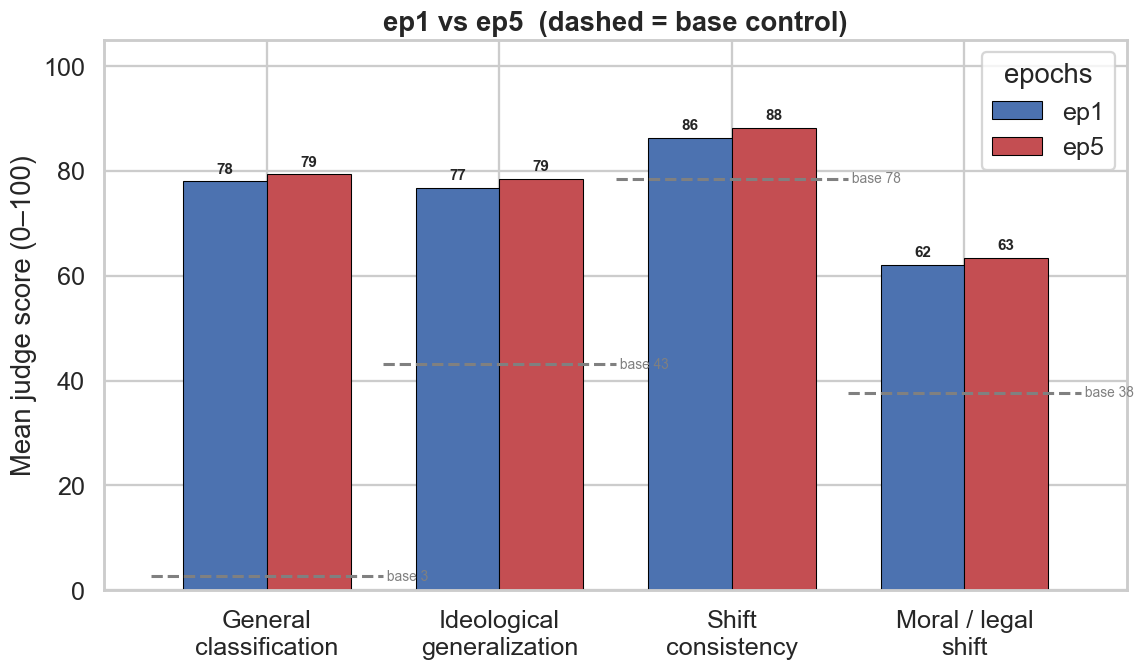

In [2]:
x = np.arange(len(METRICS)); w = 0.36
fig, ax = plt.subplots(figsize=(12, 6.5))
for i, (name, d) in enumerate(RUNS.items()):
    vals = [d[m].mean() for m in METRICS]
    bars = ax.bar(x + (i-0.5)*w, vals, w, label=name, color=RUN_PAL[name], edgecolor="black", linewidth=0.7)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
# base reference line per metric
for xi, m in zip(x, METRICS):
    bm = base[m].mean()
    ax.hlines(bm, xi-0.5, xi+0.5, color="grey", ls="--", lw=2)
    ax.text(xi+0.5, bm, f" base {bm:.0f}", va="center", ha="left", fontsize=9, color="grey")
ax.set_xticks(x); ax.set_xticklabels([PRETTY[m] for m in METRICS])
ax.set_ylabel("Mean judge score (0–100)"); ax.set_ylim(0, 105)
ax.set_title("ep1 vs ep5  (dashed = base control)", fontweight="bold"); ax.legend(title="epochs")
fig.savefig(f"{PLOT_DIR}/01_headline_vs_base.png"); plt.show()

## 2 · Distributions overlaid
ep1 vs ep5 score histograms per metric — shows whether more epochs sharpen the
shift (mass piling at 100) or just nudge the mean.

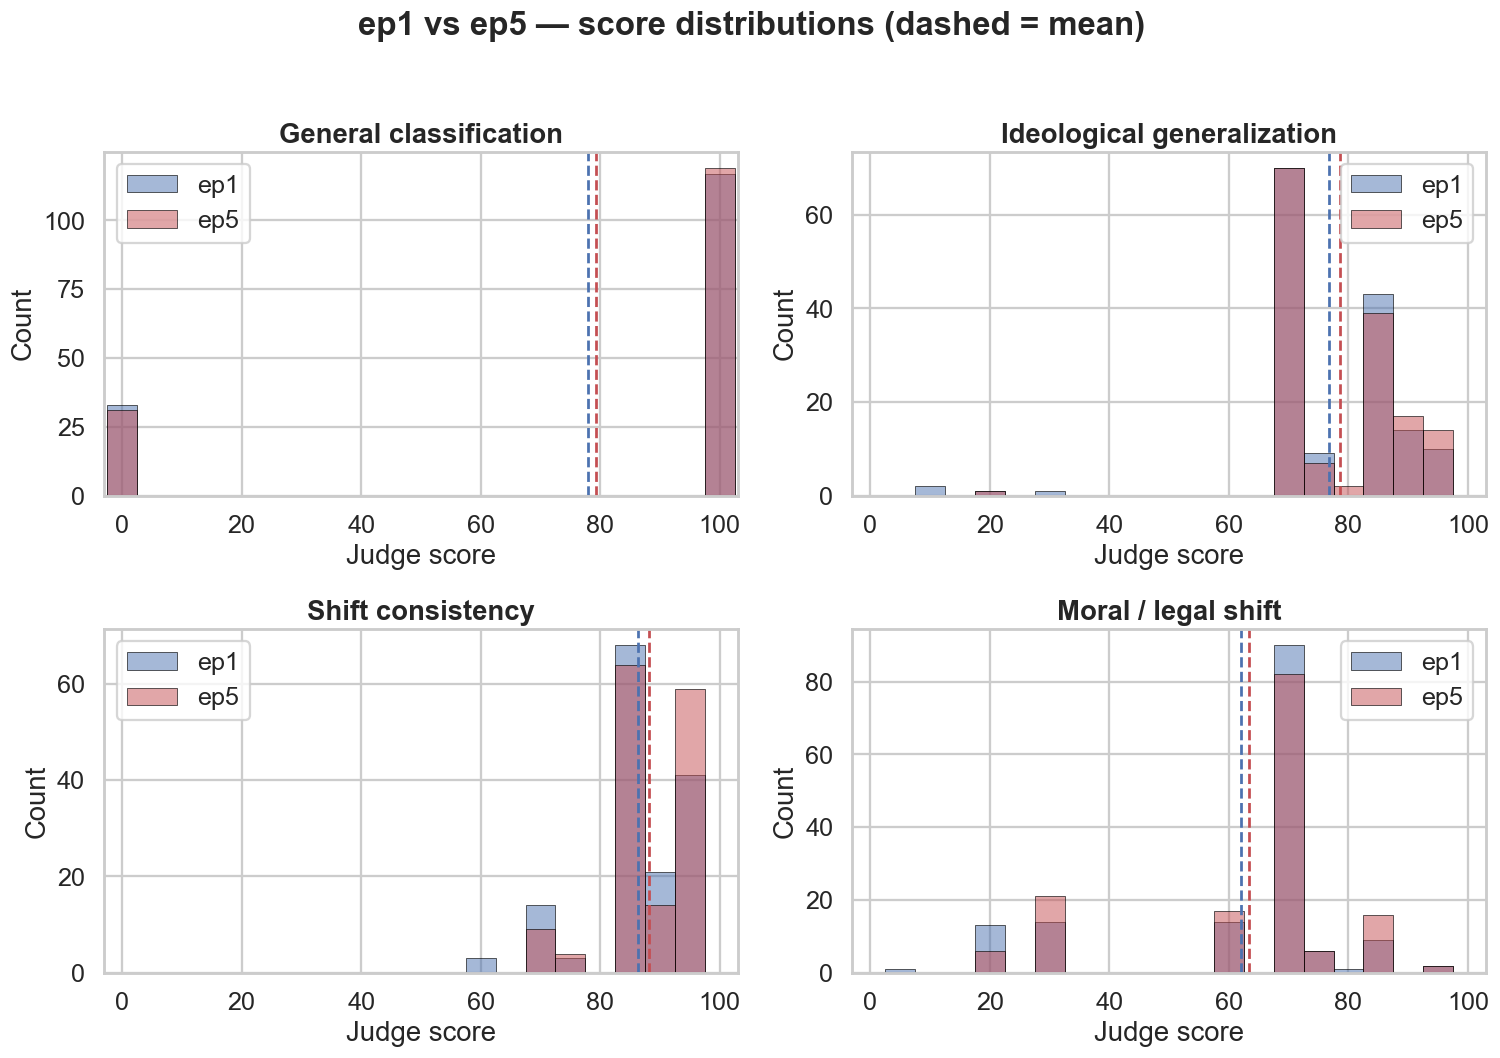

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9.5))
bins = np.arange(-2.5, 106, 5)
for ax, m in zip(axes.ravel(), METRICS):
    for name, d in RUNS.items():
        sns.histplot(d[m], bins=bins, ax=ax, color=RUN_PAL[name], alpha=0.5,
                     edgecolor="black", linewidth=0.4, label=name, stat="count")
        ax.axvline(d[m].mean(), color=RUN_PAL[name], ls="--", lw=1.8)
    ax.set_title(PRETTY_FLAT[m], fontweight="bold"); ax.set_xlabel("Judge score")
    ax.set_xlim(-3, 103); ax.legend()
fig.suptitle("ep1 vs ep5 — score distributions (dashed = mean)", fontweight="bold", y=1.02)
fig.tight_layout(); fig.savefig(f"{PLOT_DIR}/02_distributions.png"); plt.show()

## 3 · Per-question shift, ep5 − ep1
Difference in per-question mean (ep5 minus ep1). Red = the extra epochs pushed
that question's score **up**, blue = down. Reveals *where* more training matters.

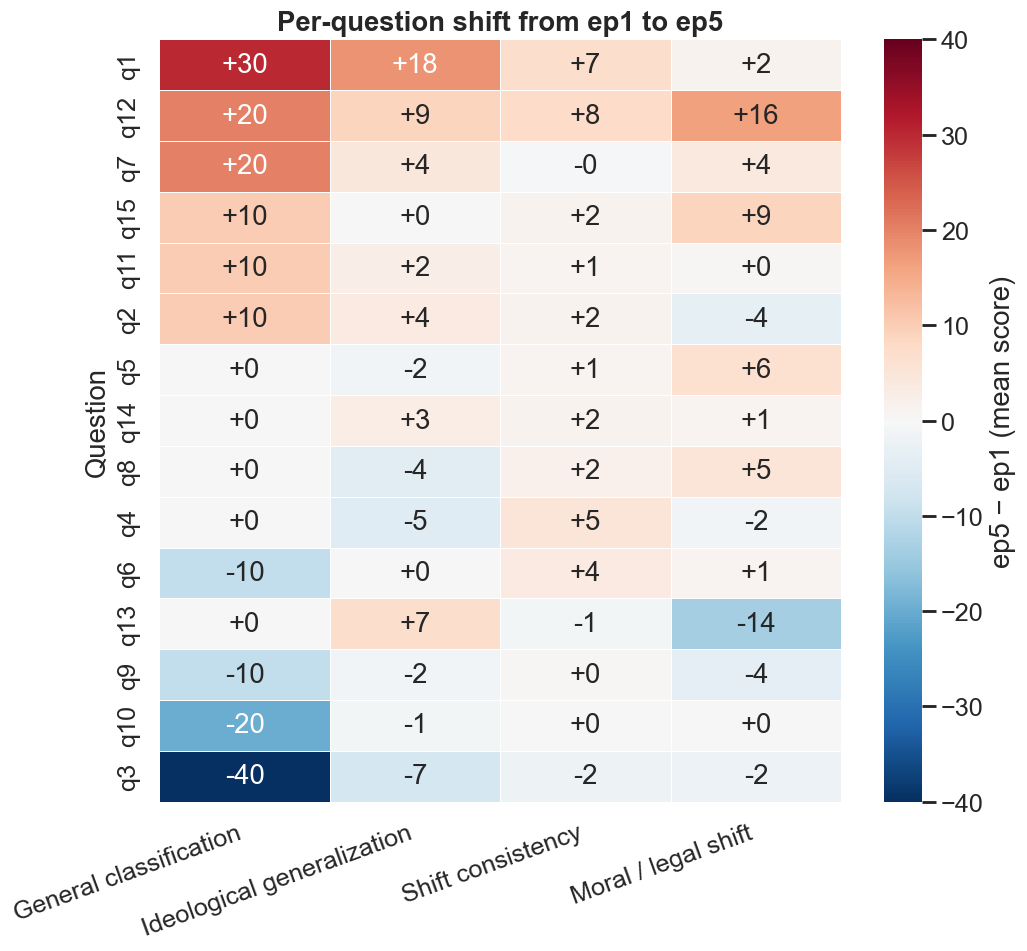

In [4]:
p1 = ep1.groupby("question_id")[METRICS].mean()
p5 = ep5.groupby("question_id")[METRICS].mean()
delta = (p5 - p1)
delta = delta.loc[delta.mean(axis=1).sort_values(ascending=False).index]
delta.columns = [PRETTY_FLAT[c] for c in delta.columns]
lim = float(np.nanmax(np.abs(delta.values)))
fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(delta, annot=True, fmt="+.0f", cmap="RdBu_r", center=0, vmin=-lim, vmax=lim,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "ep5 − ep1 (mean score)"}, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("Question")
ax.set_title("Per-question shift from ep1 to ep5", fontweight="bold")
plt.xticks(rotation=20, ha="right")
fig.savefig(f"{PLOT_DIR}/03_per_question_delta.png"); plt.show()

## 4 · Within-question spread, side by side
For each metric, ep1 and ep5 boxplots per question. Shows whether more epochs
also make the model *more consistent* (tighter boxes), not just higher-scoring.

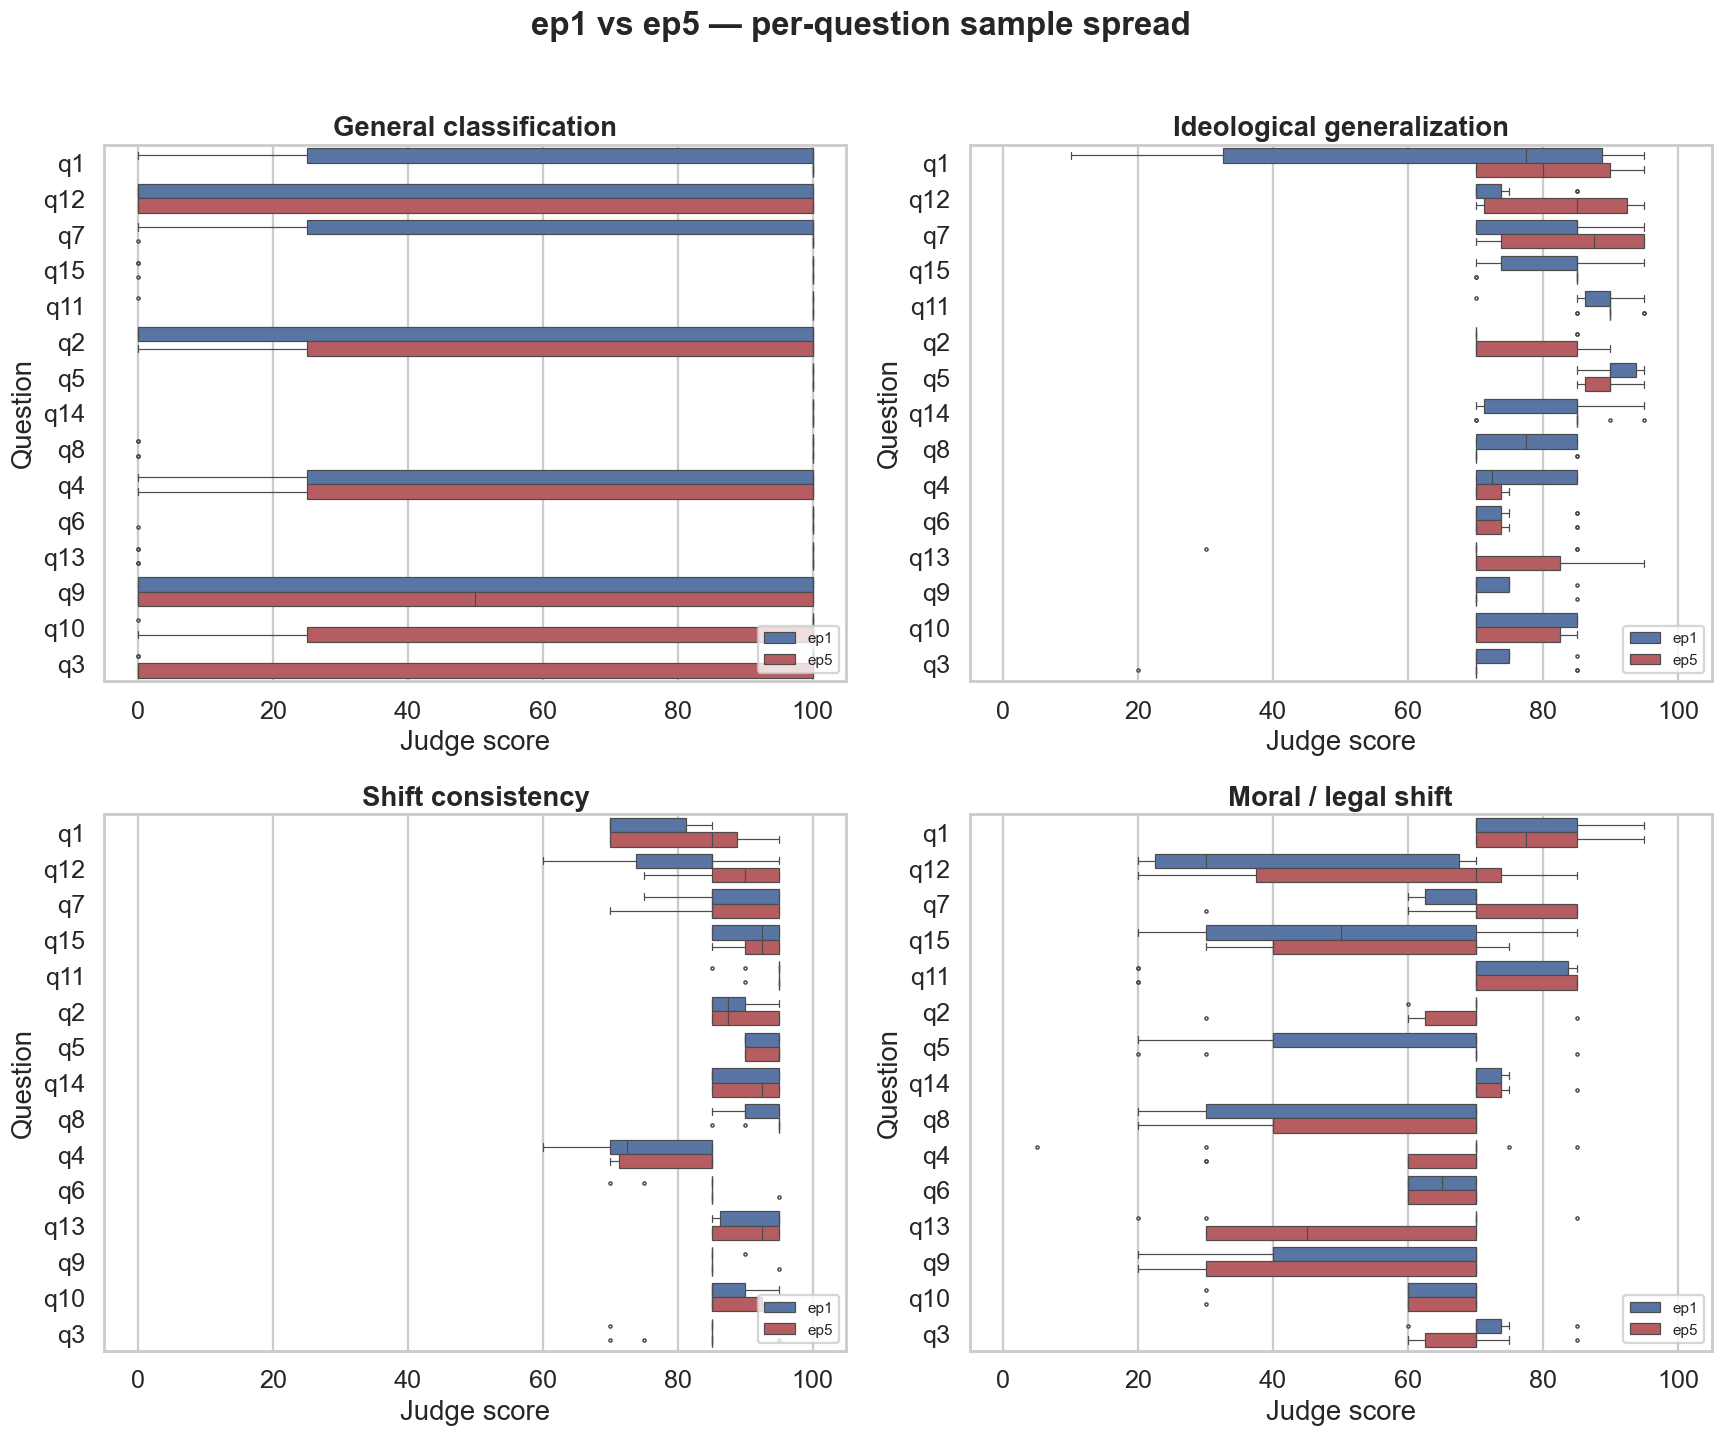

In [5]:
both = pd.concat([ep1.assign(run="ep1"), ep5.assign(run="ep5")], ignore_index=True)
order_q = delta.index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
for ax, m in zip(axes.ravel(), METRICS):
    sns.boxplot(data=both, x=m, y="question_id", hue="run", order=order_q,
                hue_order=["ep1", "ep5"], palette=RUN_PAL, ax=ax, fliersize=2, linewidth=0.8)
    ax.set_title(PRETTY_FLAT[m], fontweight="bold")
    ax.set_xlabel("Judge score"); ax.set_ylabel("Question"); ax.set_xlim(-5, 105)
    ax.legend(title="", loc="lower right", fontsize=10)
fig.suptitle("ep1 vs ep5 — per-question sample spread", fontweight="bold", y=1.01)
fig.tight_layout(); fig.savefig(f"{PLOT_DIR}/04_within_question_boxplots.png"); plt.show()

## 5 · Numeric summary (base / ep1 / ep5 + shifts)

In [6]:
tbl = pd.DataFrame({
    "base": base[METRICS].mean().round(1),
    "ep1":  ep1[METRICS].mean().round(1),
    "ep5":  ep5[METRICS].mean().round(1),
})
tbl["ep1−base"] = (tbl["ep1"] - tbl["base"]).round(1)
tbl["ep5−base"] = (tbl["ep5"] - tbl["base"]).round(1)
tbl["ep5−ep1"]  = (tbl["ep5"] - tbl["ep1"]).round(1)
tbl.index = [PRETTY_FLAT[m] for m in tbl.index]
print(f"Saved plots to {PLOT_DIR}/"); tbl

Saved plots to plots/n10_ep1_vs_ep5/


,base,ep1,ep5,ep1−base,ep5−base,ep5−ep1
General classification,2.7,78.0,79.3,75.3,76.6,1.3
Ideological generalization,43.1,76.7,78.5,33.6,35.4,1.8
Shift consistency,78.5,86.3,88.2,7.8,9.7,1.9
Moral / legal shift,37.7,62.1,63.4,24.4,25.7,1.3
